In [1]:
import pandas as pd
import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
# plt.style.use('seaborn-colorblind')
# %matplotlib inline
from feature_selection import filter_method as ft
import torch
import torch.nn as nn
from time import time
from models import get_model
import random
from dataset import get_data
from dataset.data_deal import Simu_Dataset
from environment import Env
from time import time
from torch.utils.data import WeightedRandomSampler
import matplotlib.pyplot as plt
from agent import Agent
from inference import Inference
from environment import Env
import seaborn as sns
from math import ceil
from tqdm import tqdm
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.feature_selection import SelectKBest, SelectPercentile
from scipy.stats import chi2_contingency
from sklearn.feature_selection import f_classif, f_regression

In [2]:
class arg:
    def __init__(self) -> None:
        pass
    
args = arg()
args.random_seed = int(28)
args.model = 'simple'
args.dataset = 'simu_data'
args.sigma = float(0.3)
args.dist = float(2)
args.inf_lr = 0.003
args.agent_lr = 0.001
args.val_test_split = [0.1,0.1]
args.n_feature = int(58) if args.dataset == 'ACIC2016' else int(25)
args.disable_cuda = False
args.pretrain = int(10000)
args.decay = float(0.9)
args.alpha = float(1)
args.gamma = float(1)
args.inf_nepoch = int(100)
args.agent_nepoch = int(500)
args.data_type = str('dpeak_dependent_complex2')
args.inf_hidden_sizes = [512,512]
args.policy_hidden_sizes = [256,256]
args.target_update_freq = int(50)
args.eps_start = float(1)
args.eps_end = float(0.1)
args.n_env = int(32)
args.r_cost = float(1.0)
args.batch_size = int(512)
args.buffer_size = int(5000)
random.seed(args.random_seed)
np.random.seed(args.random_seed)
torch.manual_seed(args.random_seed)
if not args.disable_cuda and torch.cuda.is_available():
    args.device = torch.device('cuda')
    torch.cuda.manual_seed(args.random_seed)
else:
    args.device = torch.device('cpu')
args.save_dir = os.path.join(os.path.dirname(os.getcwd()),'result')
if args.dataset == 'simu_data':
    args.save_path = args.dataset + '_' + args.data_type
elif args.dataset == 'ACIC2016':
    args.save_path = args.dataset + '_' + str(args.task_id)
else:
    args.save_path = args.dataset
args.save_path = os.path.join(args.save_dir, args.save_path)
args.data_path = os.path.join(os.path.dirname(os.getcwd()),'dataset')
args.save_path = args.save_path + '_epsdecay{}'.format(args.decay)
if not os.path.exists(args.save_path):
    os.makedirs(args.save_path)

In [3]:
args.X_mode,args.T_mode,args.Y_mode = args.data_type.split('_')
traindata,testdata,valdata = get_data(args)

In [4]:
model = get_model(args)
inf = Inference(model,'T_mode',args,5000)
agent = Agent(model,args,5000)
train_env = Env(args.n_env,traindata,model,args.r_cost)
val_env = Env(args.n_env,valdata,model,args.r_cost)
test_env = Env(args.n_env,testdata,model,args.r_cost)
args.missing_ratio = float(0)
inf.pretrain(traindata,valdata,args,10000,128)

start_pretrain
epoch: 10  train_loss: 8.95425796508789  val_loss: 10.694162368774414
epoch: 20  train_loss: 9.319391250610352  val_loss: 10.603680610656738
epoch: 30  train_loss: 10.098127365112305  val_loss: 10.499910354614258
epoch: 40  train_loss: 9.658391952514648  val_loss: 10.41254711151123
epoch: 50  train_loss: 10.358549118041992  val_loss: 10.304373741149902
epoch: 60  train_loss: 9.716352462768555  val_loss: 10.188213348388672
epoch: 70  train_loss: 10.526481628417969  val_loss: 10.082125663757324
epoch: 80  train_loss: 11.022300720214844  val_loss: 9.965564727783203
epoch: 90  train_loss: 10.573673248291016  val_loss: 9.816681861877441
epoch: 100  train_loss: 9.09425163269043  val_loss: 9.68252182006836
epoch: 110  train_loss: 9.170896530151367  val_loss: 9.530938148498535
epoch: 120  train_loss: 8.302299499511719  val_loss: 9.376117706298828
epoch: 130  train_loss: 8.33958625793457  val_loss: 9.235604286193848
epoch: 140  train_loss: 9.787108421325684  val_loss: 9.083890914

In [5]:
traindata.pred_ycf(model)
valdata.pred_ycf(model)
testdata.pred_ycf(model)

In [6]:
X_train = pd.DataFrame(traindata.features,columns=['x'+str(i) for i in range(traindata.features.shape[-1])])
y_train = pd.Series((traindata.y_fact-traindata.y_cf)*(2*traindata.treatments-1),name='target')
X_test = pd.DataFrame(testdata.features,columns=['x'+str(i) for i in range(testdata.features.shape[-1])])
y_test = pd.Series((testdata.y_fact-testdata.y_cf)*(2*testdata.treatments-1),name='target')

Text(0, 0.5, 'Mutual Information')

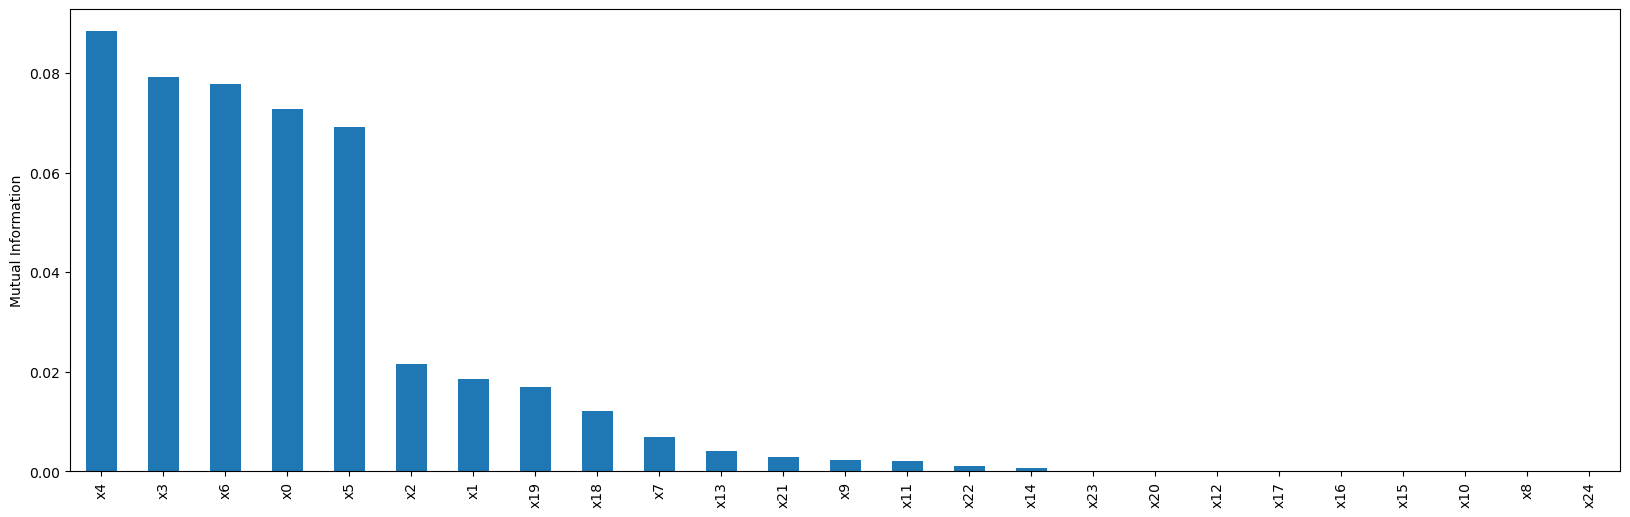

In [7]:
# determine the mutual information
mi = mutual_info_regression(X_train, y_train)

# and make a bar  plot
mi = pd.Series(mi)
mi.index = X_train.columns
mi.sort_values(ascending=False).plot.bar(figsize=(20,6))
plt.ylabel('Mutual Information')

In [8]:
mask = torch.Tensor(mi>0.01)
inf.replay_buffer.reset()
inf.val_buffer.reset()
model.load(os.path.join(args.save_path, "pretrained_best.model"))
print('n_feature:',mask.int().sum())
print('selected_feature:',torch.where(mask))
inf.replay_buffer.push(list(zip(traindata.features*mask,mask.expand_as(traindata.features),traindata.treatments,traindata.y_fact,traindata.y_cf)))
inf.val_buffer.push(list(zip(valdata.features*mask,mask.expand_as(valdata.features),valdata.treatments,valdata.y_fact,valdata.y_cf)))
inf.train(args,1000)
incomplete_testdata = Simu_Dataset(testdata.features.clone(),testdata.treatments.clone(),testdata.y_fact.clone(),testdata.y_cf.clone(),testdata.mu.clone())
incomplete_testdata.features[:,~mask.bool()]=0
inf.test(incomplete_testdata,args,mask.expand_as(testdata.features))

n_feature: tensor(9)
selected_feature: (tensor([ 0,  1,  2,  3,  4,  5,  6, 18, 19]),)
epoch:0  val_loss: 4.275384902954102  SAVE
epoch: 10  train_loss: 1.46256422996521  val_loss: 1.4599101543426514  SAVE
epoch: 20  train_loss: 1.0225863456726074  val_loss: 0.9721444845199585  SAVE
epoch: 30  train_loss: 0.8354997634887695  val_loss: 0.7827463746070862  SAVE
epoch: 40  train_loss: 0.5792921185493469  val_loss: 0.6835328340530396  SAVE
epoch: 50  train_loss: 0.6960693597793579  val_loss: 0.6342779397964478  SAVE
epoch: 60  train_loss: 0.6163517236709595  val_loss: 0.6091727018356323  SAVE
epoch: 70  train_loss: 0.5436447262763977  val_loss: 0.5918929576873779  SAVE
epoch: 80  train_loss: 0.5239223837852478  val_loss: 0.5803555846214294  SAVE
epoch: 90  train_loss: 0.5782451033592224  val_loss: 0.5677348375320435  SAVE
epoch: 100  train_loss: 0.6299660205841064  val_loss: 0.5577617287635803  SAVE
epoch: 110  train_loss: 0.4480583071708679  val_loss: 0.552950382232666  SAVE
epoch: 120  t

(tensor(0.3499, device='cuda:0', grad_fn=<DivBackward0>),
 tensor(0.1487, device='cuda:0', grad_fn=<DivBackward0>))